# 05 — NLP: Sentiment, Topics & LDA

Three NLP analyses:
1. **VADER Sentiment** — by event period and by player
2. **TF-IDF Keywords** — most distinctive words per event period
3. **LDA Topic Modeling** — latent topics in cricket posts across the full dataset

### 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

from utils import (
    get_spark, load_cricket_submissions, load_cricket_comments,
    add_player_mentions, add_time_features, label_event_period,
    save_figure, save_pandas_to_local,
    EVENT_DATES,
)

from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, avg, sum as ssum, udf, lower
from pyspark.sql.types import FloatType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import nltk

nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

### 2. Start Spark

In [2]:
spark = get_spark("05_NLP_Sentiment_LDA")
spark

:: loading settings :: url = jar:file:/home/ubuntu/spark-3.5.1-bin-hadoop3/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-36de32e9-be68-4322-829a-dfdb627e1d28;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 451ms :: artifacts dl 10ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evi

### 3. Load filtered data

In [3]:
subs = load_cricket_submissions(spark)
coms = load_cricket_comments(spark)
print("Loaded submissions and comments")

26/04/28 18:41:04 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Loaded submissions and comments


### 4. Add time features, event period, player mentions

In [4]:
subs = add_time_features(subs, ts_col="created_utc")
subs = label_event_period(subs, ts_col="created_dt")
subs = add_player_mentions(subs, text_col="title")

coms = add_time_features(coms, ts_col="created_utc")
coms = label_event_period(coms, ts_col="created_dt")
coms = add_player_mentions(coms, text_col="body")

### 5. Define VADER sentiment UDF

In [5]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

_sia = SentimentIntensityAnalyzer()

def get_compound(text):
    if text is None:
        return 0.0
    return float(_sia.polarity_scores(str(text))["compound"])

sentiment_udf = udf(get_compound, FloatType())

### 6. Score sentiment

In [6]:
subs = subs.withColumn("sentiment", sentiment_udf(col("title")))
coms = coms.withColumn("sentiment", sentiment_udf(col("body")))
print("Sentiment scores added")

Sentiment scores added


### 7. Avg sentiment by event period

In [7]:
key_periods = [
    "wc2023_group_stage",
    "wc2023_final_aftermath",
    "ipl2024",
    "t20wc2024_group_stage",
    "t20wc2024_final_aftermath",
]

sentiment_by_period = (
    subs
    .filter(col("event_period").isin(key_periods))
    .groupBy("event_period")
    .agg(count("*").alias("posts"), avg("sentiment").alias("avg_sentiment"))
    .toPandas()
)

period_order = {"wc2023_group_stage": 0, "wc2023_final_aftermath": 1, "ipl2024": 2,
                "t20wc2024_group_stage": 3, "t20wc2024_final_aftermath": 4}
sentiment_by_period["order"] = sentiment_by_period["event_period"].map(period_order)
sentiment_by_period = sentiment_by_period.sort_values("order").reset_index(drop=True)

print(sentiment_by_period[["event_period", "posts", "avg_sentiment"]])
save_pandas_to_local(sentiment_by_period, "05_sentiment_by_period.csv")

                event_period  posts  avg_sentiment
0         wc2023_group_stage  28378       0.052537
1     wc2023_final_aftermath   5917       0.051283
2                    ipl2024  69295       0.061969
3      t20wc2024_group_stage  19012       0.072327
4  t20wc2024_final_aftermath   7217       0.115754
Saved to results/tables/05_sentiment_by_period.csv


### 8. Bar chart — sentiment by period

/tmp/ipykernel_5717/1144244610.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sentiment_by_period["event_period"], rotation=20, ha="right")


Saved to results/figures/05_sentiment_by_period.png


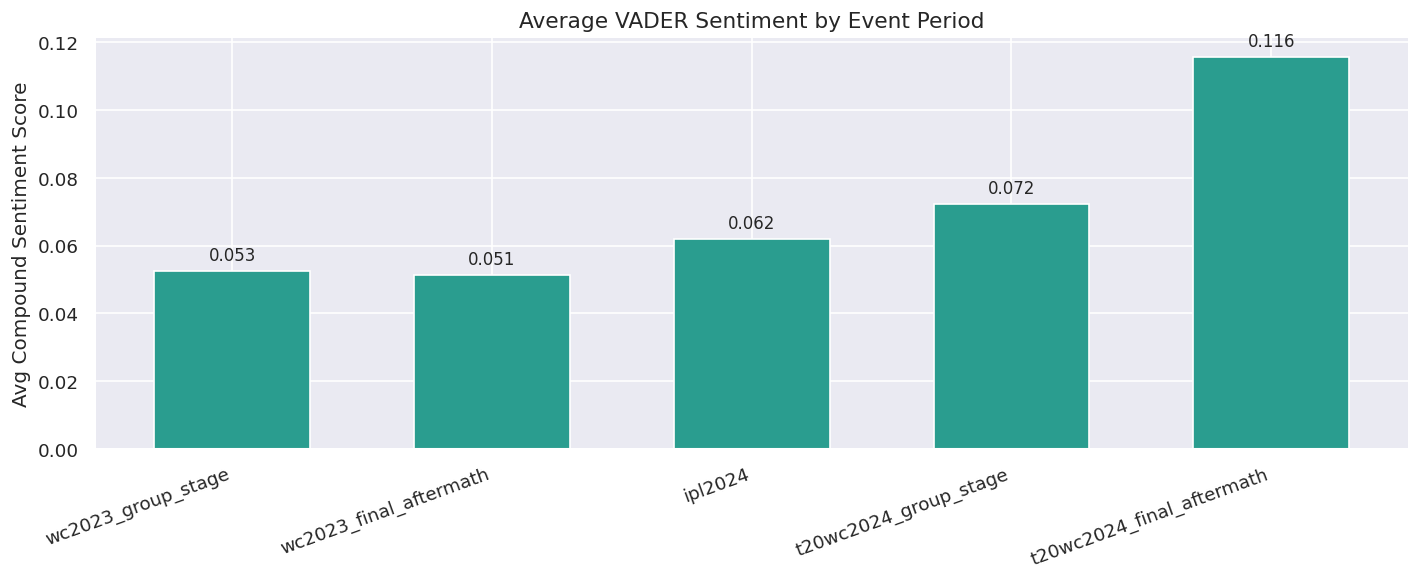

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in sentiment_by_period["avg_sentiment"]]
bars = ax.bar(sentiment_by_period["event_period"], sentiment_by_period["avg_sentiment"],
              color=bar_colors, edgecolor="white", width=0.6)
ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
ax.bar_label(bars, labels=[f"{v:.3f}" for v in sentiment_by_period["avg_sentiment"]], padding=4, fontsize=10)
ax.set_title("Average VADER Sentiment by Event Period", fontsize=13)
ax.set_ylabel("Avg Compound Sentiment Score")
ax.set_xticklabels(sentiment_by_period["event_period"], rotation=20, ha="right")
plt.tight_layout()
save_figure(fig, "05_sentiment_by_period.png")
plt.show()

### 9. Sentiment per player

In [9]:
def player_sentiment(df, player_col, player_name):
    return (
        df.filter(col(player_col))
        .agg(count("*").alias("posts"), avg("sentiment").alias("avg_sentiment"))
        .withColumn("player", F.lit(player_name))
    )

player_sentiment_df = (
    player_sentiment(subs, "mentions_dhoni", "Dhoni")
    .union(player_sentiment(subs, "mentions_kohli", "Kohli"))
    .union(player_sentiment(subs, "mentions_rohit", "Rohit"))
    .toPandas()
)
print(player_sentiment_df)
save_pandas_to_local(player_sentiment_df, "05_player_sentiment.csv")

   posts  avg_sentiment player
0   5296       0.107528  Dhoni
1   7300       0.073052  Kohli
2   9910       0.062551  Rohit
Saved to results/tables/05_player_sentiment.csv


### 10. Bar chart — sentiment per player

Saved to results/figures/05_player_sentiment.png


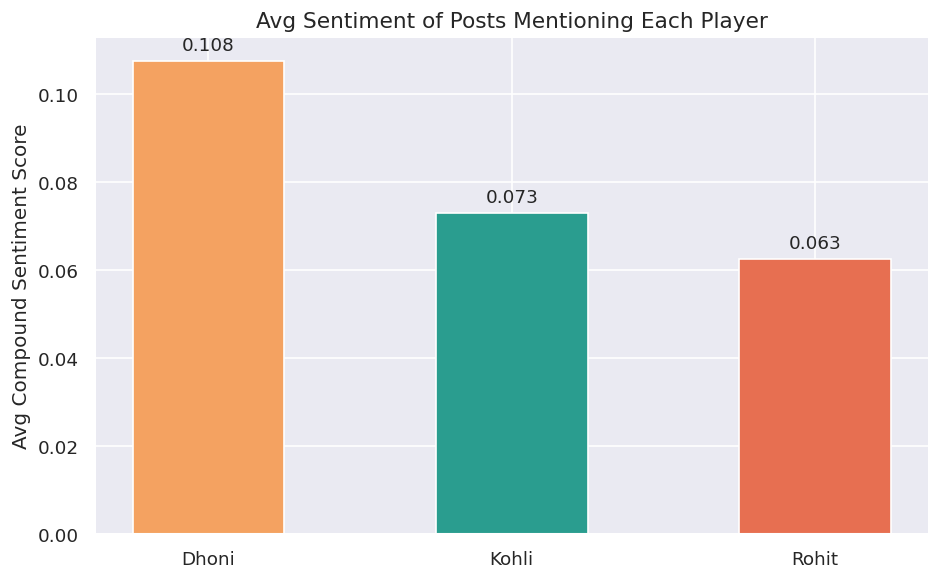

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(player_sentiment_df["player"], player_sentiment_df["avg_sentiment"],
              color=["#f4a261", "#2a9d8f", "#e76f51"], edgecolor="white", width=0.5)
ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
ax.bar_label(bars, labels=[f"{v:.3f}" for v in player_sentiment_df["avg_sentiment"]], padding=4, fontsize=11)
ax.set_title("Avg Sentiment of Posts Mentioning Each Player", fontsize=13)
ax.set_ylabel("Avg Compound Sentiment Score")
plt.tight_layout()
save_figure(fig, "05_player_sentiment.png")
plt.show()

### 11. Sentiment distribution — loss vs win aftermath

Saved to results/figures/05_sentiment_distribution_loss_vs_win.png


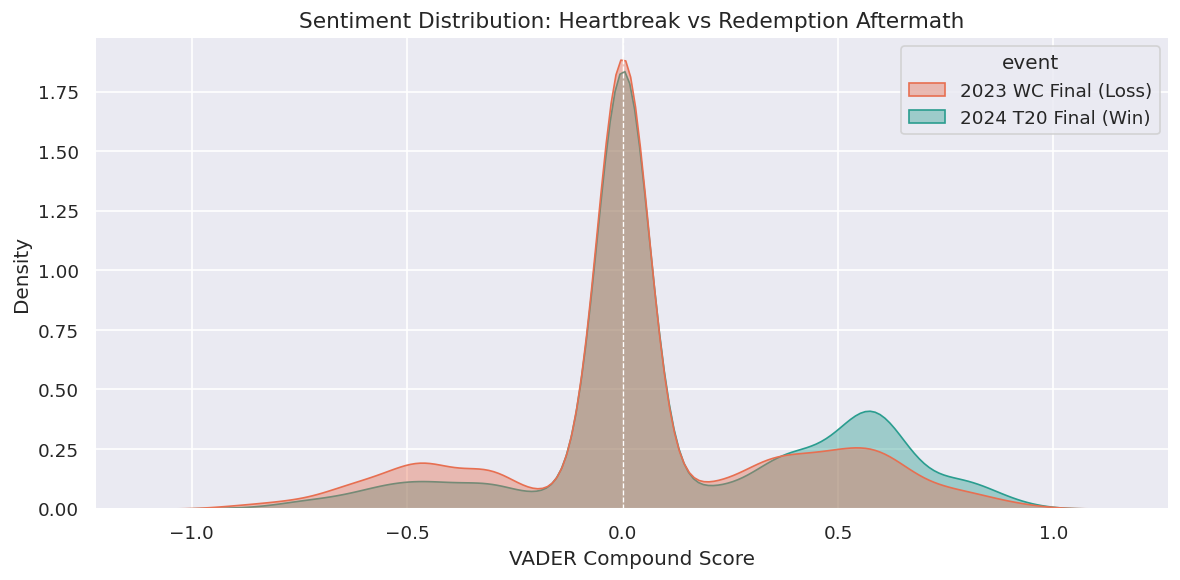

In [11]:
loss_sent = subs.filter(col("event_period") == "wc2023_final_aftermath").select("sentiment").limit(5000).toPandas()
loss_sent["event"] = "2023 WC Final (Loss)"

win_sent = subs.filter(col("event_period") == "t20wc2024_final_aftermath").select("sentiment").limit(5000).toPandas()
win_sent["event"] = "2024 T20 Final (Win)"

sent_dist = pd.concat([loss_sent, win_sent], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=sent_dist, x="sentiment", hue="event",
            palette=["#e76f51", "#2a9d8f"], fill=True, alpha=0.4, ax=ax)
ax.axvline(0, color="white", linestyle="--", linewidth=0.8)
ax.set_title("Sentiment Distribution: Heartbreak vs Redemption Aftermath", fontsize=13)
ax.set_xlabel("VADER Compound Score")
plt.tight_layout()
save_figure(fig, "05_sentiment_distribution_loss_vs_win.png")
plt.show()

### 12. TF-IDF — top keywords per event period

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

samples = {}
for period in key_periods:
    pdf = subs.filter(col("event_period") == period).select("title").limit(5000).toPandas()
    samples[period] = " ".join(pdf["title"].dropna().tolist())

period_names = list(samples.keys())
corpus = list(samples.values())

vectorizer = TfidfVectorizer(stop_words="english", max_features=500, ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

top_keywords = {}
for i, period in enumerate(period_names):
    row = tfidf_matrix[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:15]
    top_keywords[period] = [(feature_names[j], round(row[j], 4)) for j in top_idx]

for period, kws in top_keywords.items():
    print(f"\n=== {period} ===")
    for word, score in kws:
        print(f"  {word}: {score}")


=== wc2023_group_stage ===
  india: 0.3201
  world: 0.2944
  cup: 0.2559
  world cup: 0.2536
  kohli: 0.2099
  vs: 0.2091
  cricket: 0.2038
  match: 0.2008
  2023: 0.1887
  odi: 0.1593
  shami: 0.1591
  virat: 0.1555
  pakistan: 0.1532
  maxwell: 0.1419
  virat kohli: 0.1268

=== wc2023_final_aftermath ===
  india: 0.3805
  world: 0.361
  cup: 0.3381
  world cup: 0.322
  cricket: 0.2891
  australia: 0.205
  final: 0.1943
  team: 0.156
  indian: 0.1465
  match: 0.1439
  2023: 0.1284
  icc: 0.1156
  vs: 0.0968
  cup 2023: 0.0819
  cup final: 0.0819

=== ipl2024 ===
  rcb: 0.6362
  ipl: 0.282
  csk: 0.2294
  fans: 0.1997
  match: 0.1761
  team: 0.1538
  vs: 0.1457
  playoffs: 0.1371
  srh: 0.134
  2024: 0.1248
  guys: 0.11
  rr: 0.1005
  like: 0.0951
  cup: 0.0938
  season: 0.0884

=== t20wc2024_group_stage ===
  india: 0.3246
  t20: 0.282
  world: 0.275
  cup: 0.2572
  world cup: 0.2487
  pakistan: 0.2262
  match: 0.1999
  t20 world: 0.1836
  vs: 0.1774
  cricket: 0.1727
  rohit: 0.1673

### 13. Horizontal bar charts — TF-IDF keywords per period

Saved to results/figures/05_top_keywords_by_period.png


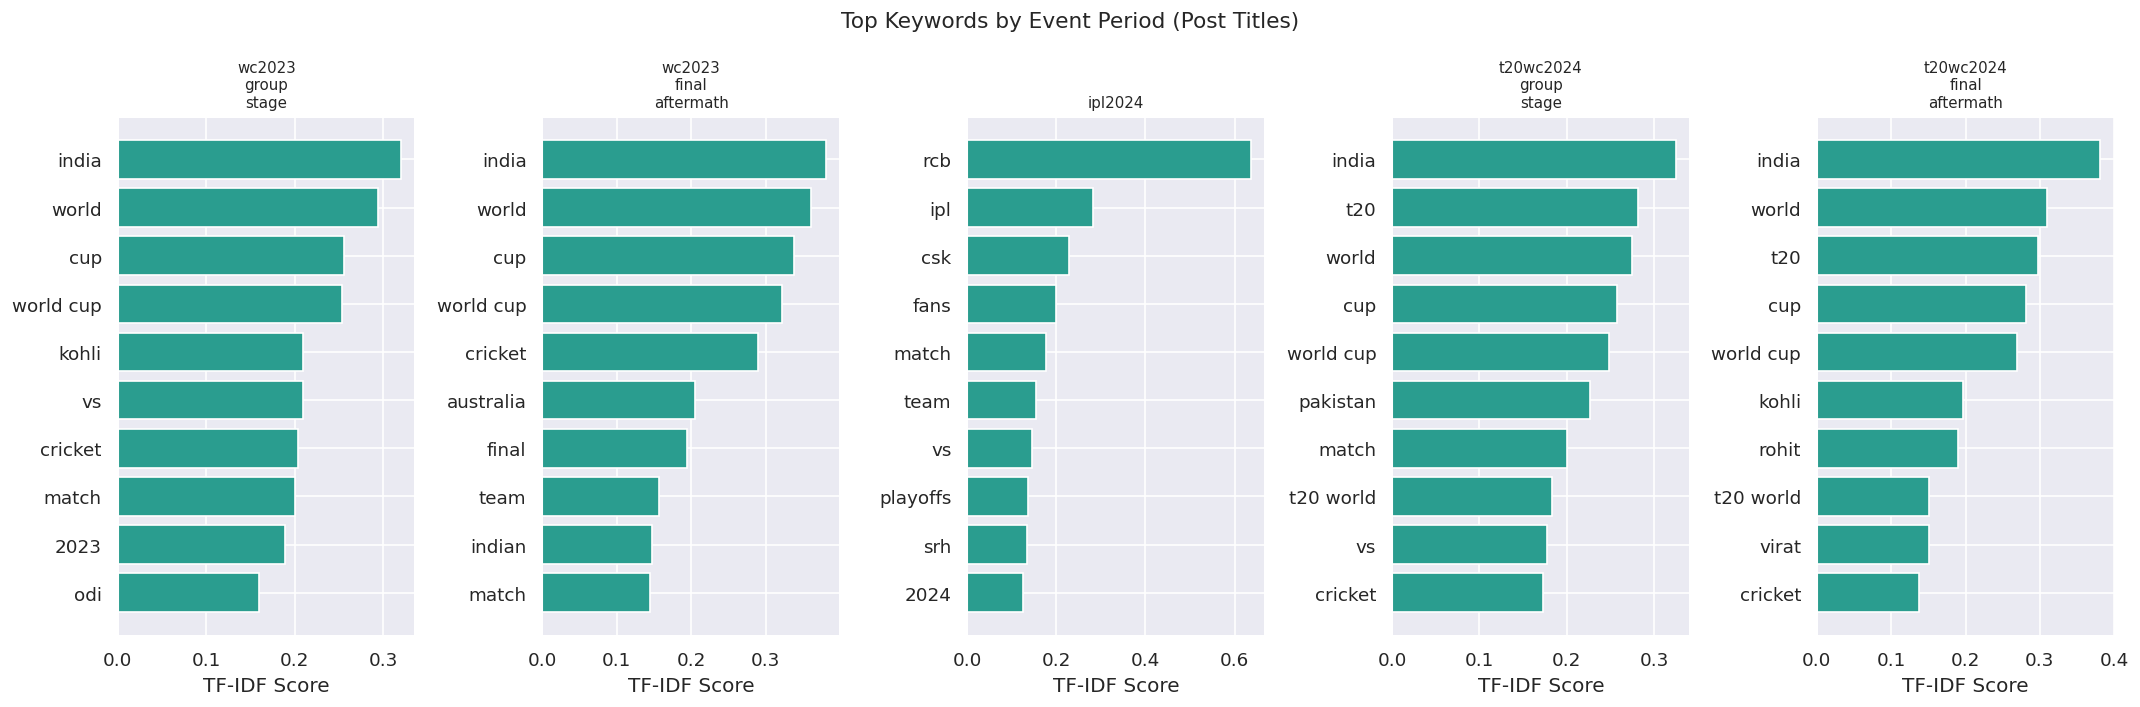

In [13]:
fig, axes = plt.subplots(1, len(key_periods), figsize=(18, 6))
for ax, period in zip(axes, key_periods):
    kws = top_keywords[period][:10]
    words = [k[0] for k in kws]
    scores = [k[1] for k in kws]
    ax.barh(words[::-1], scores[::-1], color="#2a9d8f", edgecolor="white")
    ax.set_title(period.replace("_", "\n"), fontsize=9)
    ax.set_xlabel("TF-IDF Score")
plt.suptitle("Top Keywords by Event Period (Post Titles)", fontsize=13)
plt.tight_layout()
save_figure(fig, "05_top_keywords_by_period.png")
plt.show()

### 14. LDA Topic Modeling

Use PySpark MLlib LDA on comment bodies to discover latent topics across the full cricket dataset. We use k=6 topics — one roughly per major event/theme.

In [14]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.clustering import LDA
from nltk.corpus import stopwords

# Sample comments to keep LDA tractable on t3.large
lda_df = coms.select("body").filter(col("body").isNotNull()).limit(50000)

# Tokenize
tokenizer = Tokenizer(inputCol="body", outputCol="tokens_raw")
lda_df = tokenizer.transform(lda_df)

# Remove stopwords — combine NLTK English + cricket-specific noise words
cricket_stopwords = [
    "cricket", "match", "game", "play", "played", "player", "team",
    "india", "indian", "like", "just", "good", "great", "really",
    "think", "know", "get", "one", "also", "would", "could", "even",
    "run", "runs", "ball", "balls", "over", "overs",
]
all_stopwords = list(set(stopwords.words("english") + cricket_stopwords))

remover = StopWordsRemover(inputCol="tokens_raw", outputCol="tokens", stopWords=all_stopwords)
lda_df = remover.transform(lda_df)

print("Tokenization done")

Tokenization done


### 15. Build vocabulary with CountVectorizer

In [15]:
cv = CountVectorizer(
    inputCol="tokens",
    outputCol="features",
    vocabSize=3000,
    minDF=5.0,
)
cv_model = cv.fit(lda_df)
lda_df = cv_model.transform(lda_df)
vocab = cv_model.vocabulary
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 3000


### 16. Fit LDA model (k=6 topics)

In [16]:
lda = LDA(
    k=6,
    maxIter=20,
    featuresCol="features",
    topicDistributionCol="topic_dist",
    seed=42,
)
lda_model = lda.fit(lda_df)

ll  = lda_model.logLikelihood(lda_df)
ppl = lda_model.logPerplexity(lda_df)
print(f"Log Likelihood: {ll:.2f}")
print(f"Log Perplexity: {ppl:.4f}  (lower = better)")

26/04/28 18:53:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Log Likelihood: -2085505.18
Log Perplexity: 7.4206  (lower = better)


### 17. Extract top words per topic

In [17]:
topics = lda_model.describeTopics(maxTermsPerTopic=10)
topics_df = topics.toPandas()

# Map term indices to actual words
topic_words = {}
for _, row in topics_df.iterrows():
    topic_id = row["topic"]
    words = [vocab[i] for i in row["termIndices"]]
    weights = [round(w, 4) for w in row["termWeights"]]
    topic_words[topic_id] = list(zip(words, weights))
    print(f"\nTopic {topic_id}: {', '.join(words[:6])}")

# Save topic-word table
rows = []
for tid, wlist in topic_words.items():
    for word, weight in wlist:
        rows.append({"topic": tid, "word": word, "weight": weight})
save_pandas_to_local(pd.DataFrame(rows), "05_lda_topic_words.csv")


Topic 0: lol, take, brohit, , innings, santner

Topic 1: , please, -, performed, nz, action

Topic 2: pitch, , icc, change, hai, boult

Topic 3: true, hit, fielding, showing, sara, cameraman

Topic 4: , [removed], world, australia, 🧿, iyer

Topic 5: kohli, gill, pitch, rohit, score, come
Saved to results/tables/05_lda_topic_words.csv


### 18. Chart — top words per LDA topic

/tmp/ipykernel_5717/4264730436.py:15: UserWarning: Glyph 129535 (\N{NAZAR AMULET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ubuntu/cricket_project/data_setup/../utils.py:263: UserWarning: Glyph 129535 (\N{NAZAR AMULET}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dpi=150, bbox_inches="tight")


Saved to results/figures/05_lda_topics.png


/home/ubuntu/cricket_project/cricket-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129535 (\N{NAZAR AMULET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


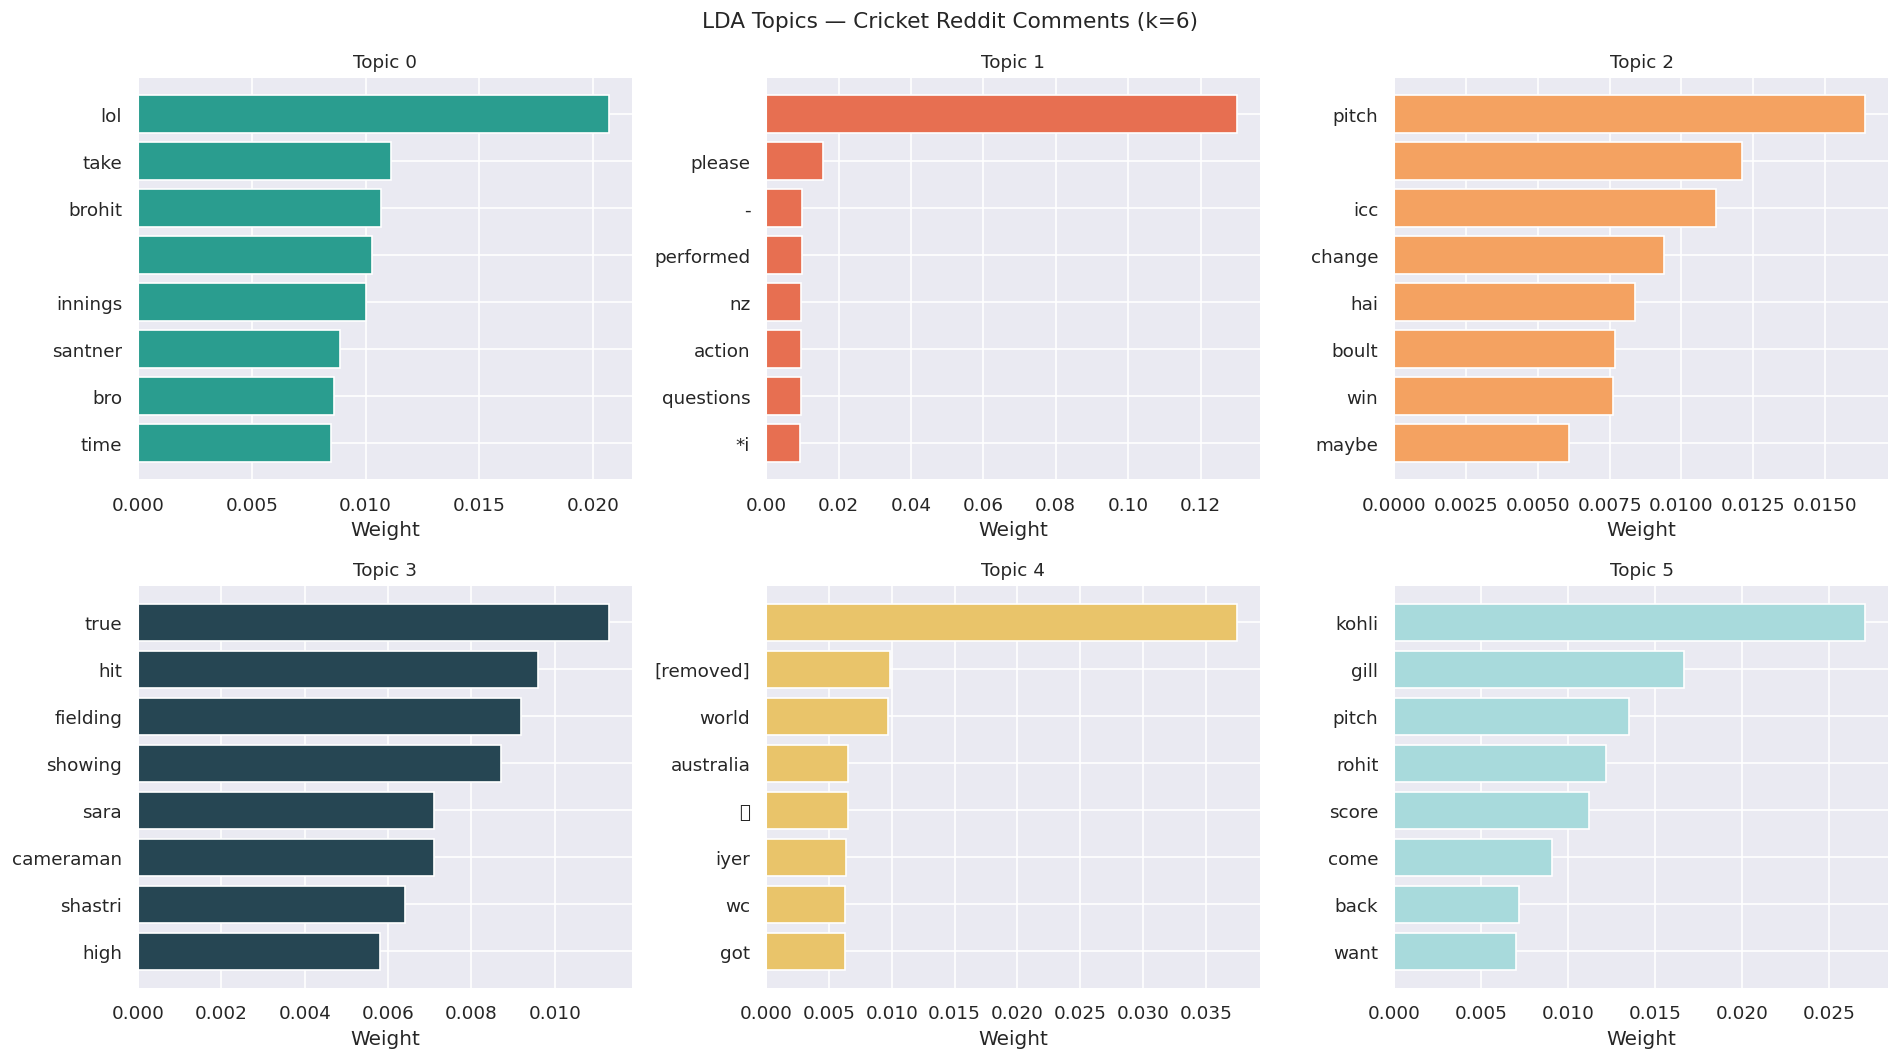

In [18]:
n_topics = len(topic_words)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

topic_colors = ["#2a9d8f", "#e76f51", "#f4a261", "#264653", "#e9c46a", "#a8dadc"]

for tid, ax in zip(range(n_topics), axes):
    words   = [w for w, _ in topic_words[tid][:8]]
    weights = [wt for _, wt in topic_words[tid][:8]]
    ax.barh(words[::-1], weights[::-1], color=topic_colors[tid], edgecolor="white")
    ax.set_title(f"Topic {tid}", fontsize=11)
    ax.set_xlabel("Weight")

plt.suptitle("LDA Topics — Cricket Reddit Comments (k=6)", fontsize=13)
plt.tight_layout()
save_figure(fig, "05_lda_topics.png")
plt.show()

### 19. Stop Spark

In [19]:
spark.stop()